# Đánh giá Chatbot tư vấn xe (DeepEval)

Notebook này đo chất lượng chatbot qua bộ test case có nhãn `expected_flow`, gọi API thật để lấy câu trả lời và retrieval context, rồi chấm điểm bằng **DeepEval GEval** (LLM-as-judge).

---
Mục tiêu

| Mục tiêu | Mô tả |
|----------|--------|
| Kiểm tra routing | Bot xử lý đúng từng loại hội thoại (tư vấn, lạc đề, chào hỏi, cần thêm thông tin) |
| Kiểm tra chất lượng trả lời | Điểm GEval theo tiêu chí nghiệp vụ từng flow |
| Tái lập được | Cùng test set, cùng API, lưu CSV và biểu đồ để so sánh giữa các lần chạy |

---
Flow

```
Test Question -> Send API -> Agentic RAG (LangGraph) -> Context/ Response -> DeepEval Evaluation
```

- **Routing intent:** `compare`, `analytics`, `specs`, `specific`, `vague`, `chitchat`, `off_topic`
- **Context đánh giá:** lấy từ `AgenticState.context`.

---
Dữ liệu test

**File:** `Data/ragas_eval_test_case.xlsx`

| Cột | Ý nghĩa |
|-----|---------|
| `user_input` | Câu hỏi / lời nói của khách |
| `expected_flow` | Nhãn luồng mong đợi: `consult`, `off-topic`, `greeting`, `need-more-info` |
| `reference` | Ground truth (tham chiếu khi so sánh; GEval chấm theo tiêu chí riêng từng flow) |
---

Metric GEval theo `expected_flow`

Mỗi flow dùng **một metric GEval riêng** (điểm 0–1). Judge model: `gpt-4o-mini`.

| `expected_flow` | Metric | Input chấm điểm | Mục tiêu nghiệp vụ |
|-----------------|--------|-------------------|---------------------|
| `consult` | `Consultation_Quality_Score` | input, actual_output, **retrieval_context** | Trả lời chính xác theo context, đủ ý, trình bày và gợi ý bán hàng tốt |
| `off-topic` | `OffTopic_Redirection_Score` | input, actual_output | Ghi nhận ngắn, không đi sâu lạc đề, bẻ lái về xe |
| `greeting` | `Chitchat_Greeting_Score` | input, actual_output | Chào lịch sự, nói rõ vai trò, hỏi mở nhu cầu xe |
| `need-more-info` | `Information_Gathering_Score` | input, actual_output | Không liệt kê xe bừa; hỏi thêm budget, kiểu xe, nhu cầu |

---

Luồng notebook (theo thứ tự cell)

| Cell | Việc làm | Output |
|------|----------|--------|
| **1** | Import, cấu hình, helper DeepEval | In trạng thái API |
| **2** | Load test cases từ Excel | `df_test` |
| **3** | Gọi `POST /chat` (hoặc đọc cache CSV) | `df_run` + `ragas_responses.csv` |
| **4** | Chia nhóm theo `expected_flow` | `flow_groups` |
| **5** | Chạy GEval từng flow | `eval_results` |
| **6** | Thống kê + lưu CSV | `deepeval_eval_{flow}.csv` |
| **7** | Biểu đồ trực quan | Bar chart + histogram phân phối |

---

Cấu hình quan trọng (Cell 1)

| Biến | Mặc định | Ghi chú |
|------|----------|---------|
| `SAMPLE_SIZE` | `None` | Giới hạn số case (debug); `None` = chạy hết |
| `REGENERATE_RESPONSES` | `False` | `True` nếu chưa có hoặc muốn gọi lại API |
| `EVAL_MODEL` | `gpt-4o-mini` | Model judge của DeepEval |
| `CONTEXT_CHAR_LIMIT` | `2000` | Cắt context trước khi chấm |

---

File kết quả

| File | Nội dung |
|------|----------|
| `Data/ragas_responses.csv` | Câu trả lời bot + `retrieved_contexts` (JSON) |
| `Data/deepeval_eval_consult.csv` | Kết quả + `Consultation_Quality_Score` |
| `Data/deepeval_eval_off-topic.csv` | Kết quả + `OffTopic_Redirection_Score` |
| `Data/deepeval_eval_greeting.csv` | Kết quả + `Chitchat_Greeting_Score` |
| `Data/deepeval_eval_need-more-info.csv` | Kết quả + `Information_Gathering_Score` |

## 1. Chuẩn bị môi trường

Import thư viện, cấu hình biến môi trường DeepEval, đường dẫn file, kiểm tra API server và OpenAI API key.

| Biến | Ý nghĩa |
|------|---------|
| `API_BASE_URL` | URL chatbot API |
| `SAMPLE_SIZE` | Giới hạn số test case (`None` = tất cả) |
| `REGENERATE_RESPONSES` | `True` để gọi lại API, `False` đọc cache CSV |


In [8]:
import json
import os
import sys
from pathlib import Path

import pandas as pd
import requests
from dotenv import load_dotenv
from tqdm.auto import tqdm

os.environ.setdefault("DEEPEVAL_TELEMETRY_OPT_OUT", "YES")
os.environ.setdefault("DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE", "180")
os.environ.setdefault("DEEPEVAL_VERBOSE_MODE", "0")

EVAL_MODEL = "gpt-4o-mini"
CONTEXT_CHAR_LIMIT = 2000

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "RAG validation" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT))

KNOWN_FLOWS = ("consult", "off-topic", "greeting", "need-more-info")

DATA_DIR = NOTEBOOK_DIR / "Data"
TEST_CASES_PATH = DATA_DIR / "ragas_eval_test_case.xlsx"
RESPONSES_PATH = DATA_DIR / "ragas_responses.csv"


def result_path_for_flow(flow: str) -> Path:
    return DATA_DIR / f"deepeval_eval_{flow}.csv"

RESULT_PATHS = {flow: result_path_for_flow(flow) for flow in KNOWN_FLOWS}

load_dotenv(PROJECT_ROOT / ".env")

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("Thieu OPENAI_API_KEY. Dat trong file .env o thu muc project.")

API_BASE_URL = os.getenv("CHATBOT_API_URL", "http://127.0.0.1:8000")
API_TIMEOUT = 120

SAMPLE_SIZE = None
REGENERATE_RESPONSES = False  # True neu chua gen response

health = requests.get(f"{API_BASE_URL}/health", timeout=10).json()
if not health.get("ready"):
    raise RuntimeError(
        f"API chua san sang tai {API_BASE_URL}. Chay: uvicorn api_server:app --reload"
    )

print(f"API: {API_BASE_URL}")
print(f"Evaluator model: {EVAL_MODEL}")
print(f"Test cases: {TEST_CASES_PATH}")


API: http://127.0.0.1:8000
Evaluator model: gpt-4o-mini
Test cases: c:\Users\nguye\Documents\ChatBot-Test\RAG validation\Data\ragas_eval_test_case.xlsx


## 2. Chuẩn bị GEval

Định nghĩa metric GEval theo từng `expected_flow`, hàm làm sạch context/reference, và hàm chạy đánh giá `run_deepeval_eval()`.

| Flow | Metric |
|------|--------|
| `consult` | `Consultation_Quality_Score` |
| `off-topic` | `OffTopic_Redirection_Score` |
| `greeting` | `Chitchat_Greeting_Score` |
| `need-more-info` | `Information_Gathering_Score` |


In [9]:
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, SingleTurnParams

from context_clean import clean_context_text, clean_reference_text


def parse_contexts(value) -> list[str]:
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        return json.loads(value)
    return [str(value)]


def trim_contexts(contexts: list[str], char_limit: int = CONTEXT_CHAR_LIMIT) -> list[str]:
    trimmed = []
    for ctx in contexts:
        text = clean_context_text(str(ctx))
        if len(text) > char_limit:
            text = text[:char_limit] + "\n...[truncated for evaluation]"
        trimmed.append(text)
    return trimmed


def _geval_metric(name: str, steps: list[str], params: list) -> GEval:
    return GEval(
        name=name,
        model=EVAL_MODEL,
        evaluation_steps=steps,
        evaluation_params=params,
        async_mode=False,
        verbose_mode=False,
    )


def make_consult_metric() -> GEval:
    return _geval_metric(
        name="Consultation_Quality_Score",
        steps=[
            "Factual correctness: check whether the bot answer aligns with specs, prices, and facts in the retrieval context.",
            "Completeness: check whether the bot addresses all parts of the user request.",
            "Presentation and sales skill: check readable formatting, vehicle highlights, advice, and alternative options.",
            "Score high if the answer is factually grounded in context, professional, and persuasive for purchase decisions.",
        ],
        params=[
            SingleTurnParams.INPUT,
            SingleTurnParams.ACTUAL_OUTPUT,
            SingleTurnParams.RETRIEVAL_CONTEXT,
        ],
    )


def make_off_topic_metric() -> GEval:
    return _geval_metric(
        name="OffTopic_Redirection_Score",
        steps=[
            "Check whether the bot recognizes the user question is off-topic and not about cars.",
            "Check whether the bot answers the off-topic subject in too much detail. If yes, penalize heavily.",
            "Check whether the bot uses redirection phrases to steer toward car buying or car needs.",
            "Score high if the bot briefly acknowledges off-topic and redirects well to cars. Score low if the bot fully follows the off-topic subject and forgets it is a car sales assistant.",
        ],
        params=[SingleTurnParams.INPUT, SingleTurnParams.ACTUAL_OUTPUT],
    )


def make_greeting_metric() -> GEval:
    return _geval_metric(
        name="Chitchat_Greeting_Score",
        steps=[
            "Check whether the bot politely and naturally responds to the user's greeting.",
            "Check whether the bot clearly states its role as a car consultation assistant.",
            "Check whether the bot ends with an open question to guide the customer into the car buying flow.",
            "Score high if all three are present: polite greeting, clear role, need-discovery question.",
        ],
        params=[SingleTurnParams.INPUT, SingleTurnParams.ACTUAL_OUTPUT],
    )


def make_need_more_info_metric() -> GEval:
    return _geval_metric(
        name="Information_Gathering_Score",
        steps=[
            "Read the user question and identify missing constraints for accurate recommendations (budget, body type, brand, use case, etc.).",
            "Check whether the bot rushes to list specific cars without enough constraints. If yes, penalize heavily.",
            "Check whether the bot asks follow-up questions to narrow scope (budget, seats, fuel type, family vs personal use).",
            "Score high if the bot asks professional clarifying questions. Score low if the bot gives generic answers or unsupported car lists.",
        ],
        params=[SingleTurnParams.INPUT, SingleTurnParams.ACTUAL_OUTPUT],
    )


FLOW_METRIC_FACTORIES = {
    "consult": lambda: [make_consult_metric()],
    "off-topic": lambda: [make_off_topic_metric()],
    "greeting": lambda: [make_greeting_metric()],
    "need-more-info": lambda: [make_need_more_info_metric()],
}

FLOW_SCORE_COLS = {
    "consult": ["Consultation_Quality_Score"],
    "off-topic": ["OffTopic_Redirection_Score"],
    "greeting": ["Chitchat_Greeting_Score"],
    "need-more-info": ["Information_Gathering_Score"],
}


def _score_column(metric) -> str:
    return metric.name


def build_test_case(row: pd.Series) -> LLMTestCase:
    contexts = trim_contexts(parse_contexts(row["retrieved_contexts"]))
    reference = str(row.get("reference", "") or "").strip()
    if reference.lower() == "nan":
        reference = ""

    return LLMTestCase(
        input=str(row["user_input"]),
        actual_output=str(row["response"]),
        expected_output=reference or None,
        retrieval_context=contexts or None,
    )


def run_deepeval_eval(df: pd.DataFrame, metric_factory, label: str):
    if df.empty:
        print(f"[{label}] Bo trong, bo qua.")
        return None

    template_metrics = metric_factory()
    score_cols = [_score_column(m) for m in template_metrics]
    print(
        f"[{label}] Danh gia {len(df)} mau voi {len(score_cols)} metrics (DeepEval)..."
    )

    scores = {col: [] for col in score_cols}
    rows = list(df.iterrows())

    pbar = tqdm(
        rows,
        total=len(rows),
        desc=label,
        leave=True,
        mininterval=0.5,
        dynamic_ncols=True,
    )

    for _, row in pbar:
        test_case = build_test_case(row)
        row_metrics = metric_factory()

        for metric, col in zip(row_metrics, score_cols):
            try:
                metric.measure(
                    test_case,
                    _show_indicator=False,
                    _log_metric_to_confident=False,
                )
                scores[col].append(metric.score)
            except Exception as exc:
                pbar.write(f"  Loi {col}: {exc}")
                scores[col].append(None)

    pbar.close()

    df_scores = pd.DataFrame(scores)
    cols = [c for c in df.columns if c != "retrieved_contexts"]
    df_out = pd.concat(
        [df[cols].reset_index(drop=True), df_scores.reset_index(drop=True)],
        axis=1,
    )
    return df_out


def load_test_cases(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df["user_input"] = df["user_input"].astype(str).str.strip()
    df["expected_flow"] = df["expected_flow"].astype(str).str.strip()
    if "reference" in df.columns:
        df["reference"] = (
            df["reference"].astype(str).str.strip().apply(clean_reference_text)
        )
    unknown = df[~df["expected_flow"].isin(KNOWN_FLOWS)]["expected_flow"].unique()
    if len(unknown):
        raise ValueError(f"expected_flow khong hop le: {unknown}")
    return df

print("GEval helpers ready.")


GEval helpers ready.


## 3. Load test cases

Đọc file Excel `ragas_eval_test_case.xlsx`, làm sạch cột `reference`, kiểm tra nhãn `expected_flow` hợp lệ.


In [10]:
df_test = load_test_cases(TEST_CASES_PATH)
# df_test = df_test[df_test['expected_flow'] == 'off-topic']

if SAMPLE_SIZE is not None:
    df_test = df_test.head(SAMPLE_SIZE).reset_index(drop=True)

print(f"Loaded {len(df_test)} test cases")
print(df_test["expected_flow"].value_counts())
df_test.head()


Loaded 80 test cases
expected_flow
consult           27
need-more-info    23
off-topic         15
greeting          15
Name: count, dtype: int64


,user_input,expected_flow,reference
0,What is the capital of France?,off-topic,That's a great question! The capital of France...
1,Can you write a python script for a calculator?,off-topic,That sounds like a great project! Speaking of ...
2,Who won the World Cup in 2022?,off-topic,That's an exciting topic! Speaking of competit...
3,What's the best recipe for chocolate chip cook...,off-topic,That sounds delicious! Speaking of sweet treat...
4,Can you tell me a joke about dogs?,off-topic,That's a fun topic! Dogs always bring a smile....


## 4. Gọi API lấy response

Gọi `POST /chat` với `return_context=True` để lấy câu trả lời bot và retrieval context.

- `REGENERATE_RESPONSES = True`: gọi API mới và lưu `ragas_responses.csv`
- `REGENERATE_RESPONSES = False`: đọc file CSV đã lưu


In [11]:
def chat_via_api(message: str, session_id: str) -> dict:
    resp = requests.post(
        f"{API_BASE_URL}/chat",
        json={
            "session_id": session_id,
            "message": message,
            "reset": True,
            "return_context": True,
        },
        timeout=API_TIMEOUT,
    )
    resp.raise_for_status()
    return resp.json()


if REGENERATE_RESPONSES or not RESPONSES_PATH.exists():
    responses = []
    contexts_list = []

    for idx, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Calling API"):
        session_id = f"ragas-eval-{idx}"
        data = chat_via_api(row["user_input"], session_id)
        responses.append(data["answer"])
        contexts_list.append(data.get("retrieved_contexts") or [])

    df_run = df_test.copy()
    df_run["response"] = responses
    df_run["retrieved_contexts"] = contexts_list

    df_save = df_run.copy()
    df_save["retrieved_contexts"] = df_save["retrieved_contexts"].apply(
        lambda c: json.dumps(c, ensure_ascii=False)
    )
    df_save.to_csv(RESPONSES_PATH, index=False)
    print(f"Saved responses: {RESPONSES_PATH}")
else:
    df_run = pd.read_csv(RESPONSES_PATH)
    df_run["retrieved_contexts"] = df_run["retrieved_contexts"].apply(parse_contexts)
    if "expected_flow" not in df_run.columns:
        df_run = df_run.merge(
            df_test[["user_input", "expected_flow"]],
            on="user_input",
            how="left",
        )
    print(f"Loaded cached responses: {RESPONSES_PATH}")

df_run[["user_input", "response", "reference"]].head()


Loaded cached responses: c:\Users\nguye\Documents\ChatBot-Test\RAG validation\Data\ragas_responses.csv


,user_input,response,reference
0,What is the capital of France?,That's a great question! The capital of France...,That's a great question! The capital of France...
1,Can you write a python script for a calculator?,That sounds like a great project! Speaking of ...,That sounds like a great project! Speaking of ...
2,Who won the World Cup in 2022?,That's a great question! The 2022 World Cup wa...,That's an exciting topic! Speaking of competit...
3,What's the best recipe for chocolate chip cook...,That sounds delicious! Speaking of sweet thing...,That sounds delicious! Speaking of sweet treat...
4,Can you tell me a joke about dogs?,"That's a fun topic! Speaking of dogs, do you h...",That's a fun topic! Dogs always bring a smile....


## 5. Chia nhóm theo expected_flow

Tách `df_run` thành 4 nhóm: `consult`, `off-topic`, `greeting`, `need-more-info`.


In [12]:
df_run = pd.read_csv(RESPONSES_PATH)

flow_groups = {
    flow: df_run[df_run["expected_flow"] == flow].reset_index(drop=True)
    for flow in KNOWN_FLOWS
}

for flow, subset in flow_groups.items():
    print(f"{flow}: {len(subset)}")


consult: 27
off-topic: 15
greeting: 15
need-more-info: 23


## 6. Chạy đánh giá GEval

Chấm điểm từng nhóm bằng metric tương ứng. Kết quả lưu trong `eval_results`.


In [13]:
eval_results = {}

for flow, subset in flow_groups.items():
    eval_results[flow] = run_deepeval_eval(
        subset, FLOW_METRIC_FACTORIES[flow], flow
    )

if eval_results.get("consult") is not None:
    display(eval_results["consult"].head())


[consult] Danh gia 27 mau voi 1 metrics (DeepEval)...


consult:   0%|          | 0/27 [00:00<?, ?it/s]

[off-topic] Danh gia 15 mau voi 1 metrics (DeepEval)...


off-topic:   0%|          | 0/15 [00:00<?, ?it/s]

[greeting] Danh gia 15 mau voi 1 metrics (DeepEval)...


greeting:   0%|          | 0/15 [00:00<?, ?it/s]

[need-more-info] Danh gia 23 mau voi 1 metrics (DeepEval)...


need-more-info:   0%|          | 0/23 [00:00<?, ?it/s]

,user_input,expected_flow,reference,response,Consultation_Quality_Score
0,What is the most expensive car in the inventory?,consult,The most expensive car in the inventory is pri...,The most expensive car in the inventory is pri...,0.824138
1,Which Ford model is the most expensive?,consult,The most expensive Ford model currently listed...,The most expensive Ford model listed is the 20...,0.852574
2,How many electric cars do you have?,consult,"Currently, there are no electric cars listed i...","Currently, there are no electric cars listed i...",0.789412
3,How many gasoline cars do you have?,consult,"There are a total of 2,324 gasoline cars in th...","We have a total of 2,324 gasoline cars in our ...",1.000000
4,What's the cheapest Honda Civic available?,consult,The cheapest Honda Civic available is the 2013...,The cheapest Honda Civic available is the **20...,0.850000


## 7. Thống kê và lưu CSV

In bảng thống kê (mean, std, min, max) và lưu file `deepeval_eval_{flow}.csv`.


In [25]:
def print_summary(df: pd.DataFrame, title: str, score_cols: list[str]):
    print(f"\n=== {title} ===")
    if df is None or df.empty:
        print("Khong co du lieu.")
        return
    cols = [c for c in score_cols if c in df.columns]
    if cols:
        print(df[cols].describe().round(3))
    else:
        print(df.describe(include="number"))


for flow in KNOWN_FLOWS:
    print_summary(
        eval_results.get(flow),
        f"{flow} ({', '.join(FLOW_SCORE_COLS[flow])})",
        FLOW_SCORE_COLS[flow],
    )

for flow, df in eval_results.items():
    if df is not None:
        path = RESULT_PATHS[flow]
        df.to_csv(path, index=False, encoding="utf-8")
        print(f"Saved: {path}")



=== consult (score_col) ===
       Consultation_Quality_Score
count                   27.000000
mean                     0.786506
std                      0.178808
min                      0.249895
25%                      0.678774
50%                      0.852574
75%                      0.894946
max                      1.000000

=== off-topic (score_col) ===
       OffTopic_Redirection_Score
count                   15.000000
mean                     0.820894
std                      0.020406
min                      0.793512
25%                      0.808560
50%                      0.814805
75%                      0.825701
max                      0.868888

=== greeting (score_col) ===
       Chitchat_Greeting_Score
count                15.000000
mean                  0.919935
std                   0.136195
min                   0.526648
25%                   0.876108
50%                   0.998594
75%                   1.000000
max                   1.000000

=== need-more-info

## 8. Trực quan hóa kết quả

- Biểu đồ cột: điểm trung bình theo 4 `expected_flow`, có ngưỡng **0.7**
- Biểu đồ phân phối: histogram từng flow (2x2)

Nguồn dữ liệu: `eval_results` (sau ##6). Chỉ đọc CSV nếu restart kernel mà chưa chạy lại ##6.


Nguon du lieu: eval_results
  - Consult: n=27, mean=0.787
  - Off-topic: n=15, mean=0.821
  - Greeting: n=15, mean=0.920
  - Need more info: n=23, mean=0.853


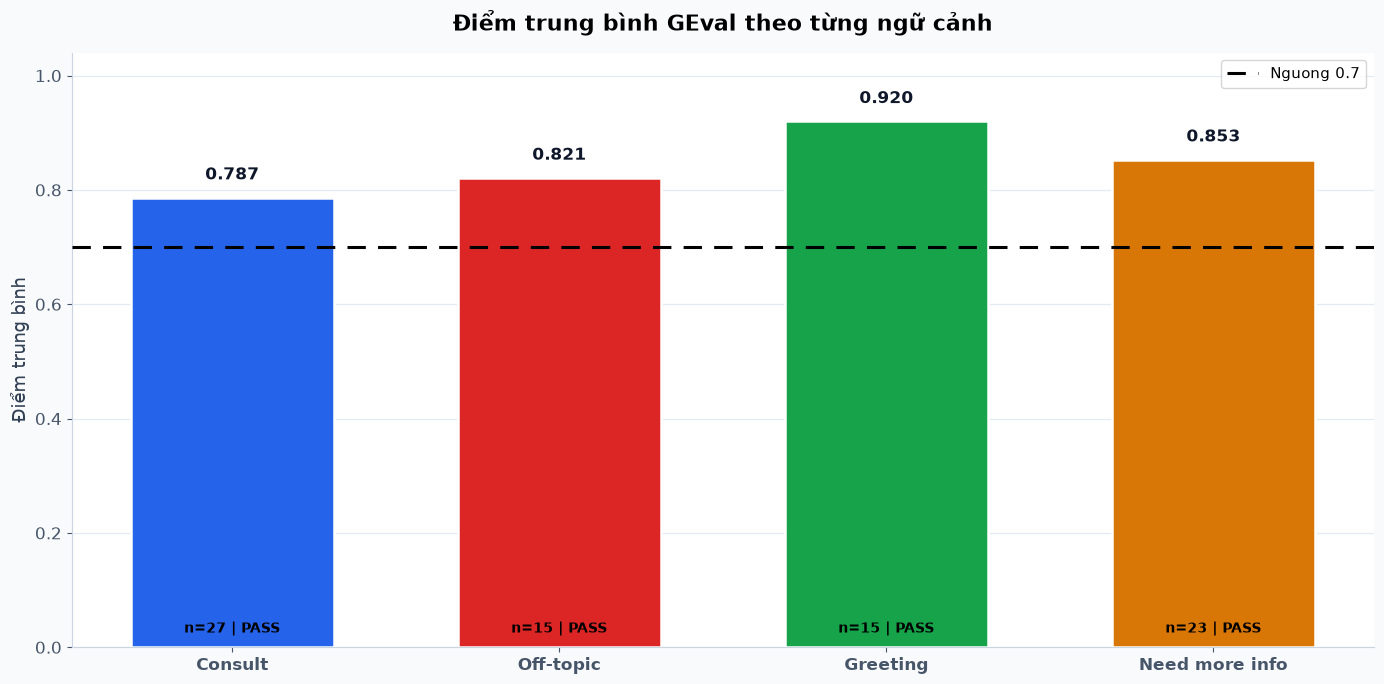

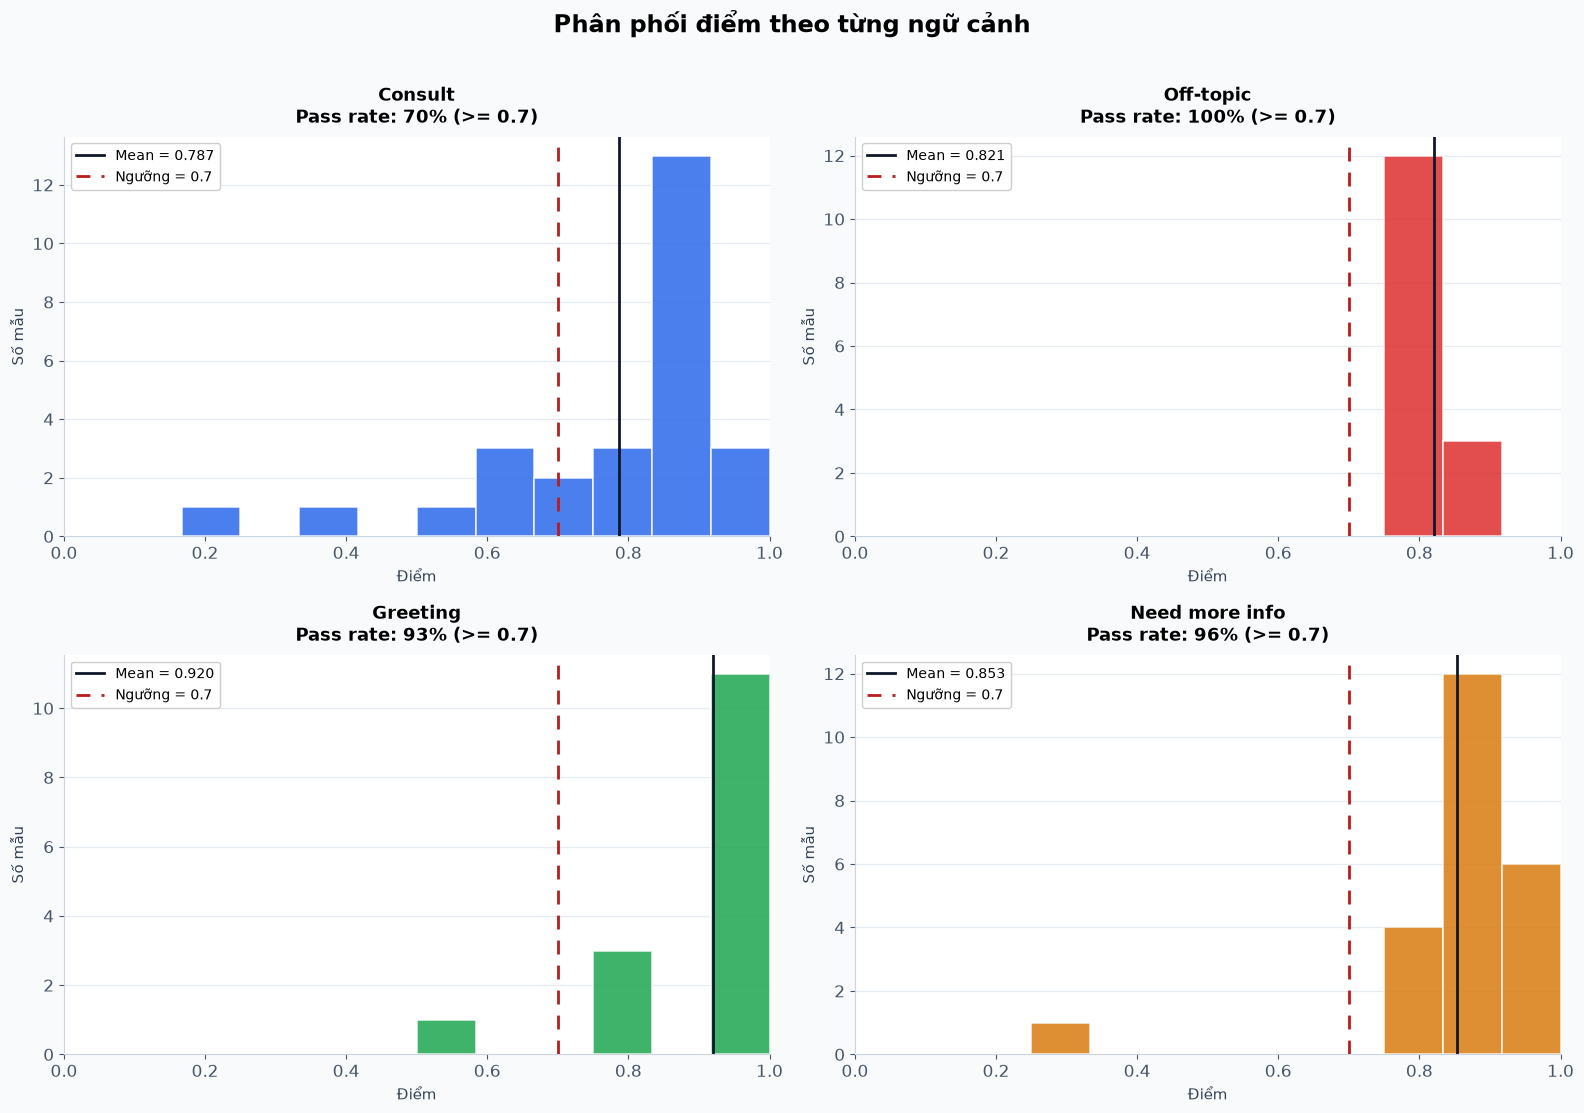


Bang tom tat:


,expected_flow,flow_label,mean,std,count
0,consult,Consult,0.787,0.179,27
1,off-topic,Off-topic,0.821,0.020,15
2,greeting,Greeting,0.920,0.136,15
3,need-more-info,Need more info,0.853,0.130,23


In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.facecolor": "#f8fafc",
    "axes.facecolor": "#ffffff",
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": "#334155",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "font.size": 12,
    "grid.color": "#e2e8f0",
    "grid.linewidth": 0.9,
    "xtick.color": "#475569",
    "ytick.color": "#475569",
})

FLOW_LABELS = {
    "consult": "Consult",
    "off-topic": "Off-topic",
    "greeting": "Greeting",
    "need-more-info": "Need more info",
}

FLOW_COLORS = {
    "consult": "#2563eb",
    "off-topic": "#dc2626",
    "greeting": "#16a34a",
    "need-more-info": "#d97706",
}

THRESHOLD = 0.7


def _resolve_score_col(df: pd.DataFrame, flow: str) -> str | None:
    for col in FLOW_SCORE_COLS.get(flow, []):
        if col in df.columns:
            return col
    candidates = [c for c in df.columns if c.endswith("_Score")]
    return candidates[0] if len(candidates) == 1 else None


def build_score_long_df(results: dict) -> pd.DataFrame:
    rows = []
    for flow in KNOWN_FLOWS:
        df = results.get(flow)
        if df is None or df.empty:
            continue

        score_col = _resolve_score_col(df, flow)
        if score_col is None:
            print(f"Khong tim thay cot diem cho flow: {flow}")
            continue

        subset = df
        if "expected_flow" in df.columns:
            subset = df[df["expected_flow"] == flow]

        for score in pd.to_numeric(subset[score_col], errors="coerce").dropna():
            rows.append(
                {
                    "expected_flow": flow,
                    "flow_label": FLOW_LABELS.get(flow, flow),
                    "metric": score_col,
                    "score": float(score),
                }
            )
    return pd.DataFrame(rows)


def _prepare_data(results: dict):
    data = {k: v for k, v in results.items() if v is not None and not v.empty}
    if not data:
        raise ValueError("eval_results rong. Chay lai ##6.")

    score_df = build_score_long_df(data)
    if score_df.empty:
        raise ValueError("Khong co du lieu hop le trong eval_results.")

    flow_order = [f for f in KNOWN_FLOWS if f in score_df["expected_flow"].unique()]
    summary = (
        score_df.groupby("expected_flow", as_index=False)["score"]
        .agg(mean="mean", std="std", count="count")
        .set_index("expected_flow")
        .loc[flow_order]
        .reset_index()
    )
    summary["flow_label"] = summary["expected_flow"].map(FLOW_LABELS)
    summary["color"] = summary["expected_flow"].map(FLOW_COLORS)

    print("Nguon du lieu: eval_results")
    for _, row in summary.iterrows():
        print(
            f"  - {row['flow_label']}: n={int(row['count'])}, mean={row['mean']:.3f}"
        )

    return score_df, summary, flow_order


def plot_mean_bar_chart(summary: pd.DataFrame):
    labels = summary["flow_label"].tolist()
    means = summary["mean"].tolist()
    counts = summary["count"].tolist()
    colors = summary["color"].tolist()

    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(labels))
    bars = ax.bar(
        x,
        means,
        width=0.62,
        color=colors,
        edgecolor="white",
        linewidth=1.8,
        zorder=3,
    )

    ax.axhline(
        THRESHOLD,
        color="#000000",
        linestyle=(0, (6, 4)),
        linewidth=2.2,
        label=f"Nguong {THRESHOLD}",
        zorder=10,
    )

    ymax = max(max(means) + 0.12, THRESHOLD + 0.1, 1.0)
    ax.set_ylim(0, ymax)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12, fontweight="semibold")
    ax.set_ylabel("Điểm trung bình", fontsize=13)
    ax.set_title(
        "Điểm trung bình GEval theo từng ngữ cảnh",
        fontsize=16,
        pad=16,
    )
    ax.yaxis.grid(True, alpha=0.9)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, mean_val, n in zip(bars, means, counts):
        status = "PASS" if mean_val >= THRESHOLD else "FAIL"
        status_color = "#000000" 
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.025,
            f"{mean_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color="#0f172a",
        )
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            0.02,
            f"n={int(n)} | {status}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=status_color,
            fontweight="semibold",
        )

    ax.legend(loc="upper right", frameon=True, fontsize=11)
    fig.tight_layout()
    plt.show()


def plot_distribution_charts(score_df: pd.DataFrame, flow_order: list[str]):
    n_flows = len(flow_order)
    ncols = 2
    nrows = int(np.ceil(n_flows / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 5.5 * nrows),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for i, flow in enumerate(flow_order):
        ax = axes_flat[i]
        scores = score_df.loc[score_df["expected_flow"] == flow, "score"].values
        color = FLOW_COLORS.get(flow, "#64748b")
        label = FLOW_LABELS.get(flow, flow)
        mean_val = float(np.mean(scores))
        pass_rate = float(np.mean(scores >= THRESHOLD) * 100)

        ax.hist(
            scores,
            bins=12,
            range=(0, 1),
            color=color,
            alpha=0.82,
            edgecolor="white",
            linewidth=1.2,
            zorder=3,
        )
        ax.axvline(
            mean_val,
            color="#0f172a",
            linestyle="-",
            linewidth=2,
            label=f"Mean = {mean_val:.3f}",
            zorder=4,
        )
        ax.axvline(
            THRESHOLD,
            color="#b91c1c",
            linestyle=(0, (5, 4)),
            linewidth=2,
            label=f"Ngưỡng = {THRESHOLD}",
            zorder=4,
        )

        ax.set_xlim(0, 1)
        ax.set_xlabel("Điểm", fontsize=11)
        ax.set_ylabel("Số mẫu", fontsize=11)
        ax.set_title(
            f"{label}\nPass rate: {pass_rate:.0f}% (>= {THRESHOLD})",
            fontsize=13,
            pad=10,
        )
        ax.yaxis.grid(True, alpha=0.85)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(loc="upper left", fontsize=10, framealpha=0.95)

    for j in range(n_flows, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(
        "Phân phối điểm theo từng ngữ cảnh",
        fontsize=17,
        fontweight="bold",
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


def plot_eval_charts(results: dict):
    score_df, summary, flow_order = _prepare_data(results)
    plot_mean_bar_chart(summary)
    plot_distribution_charts(score_df, flow_order)

    print("\nBang tom tat:")
    display(summary[["expected_flow", "flow_label", "mean", "std", "count"]].round(3))
    return score_df


score_long_df = plot_eval_charts(eval_results)

